# 🛒 E-Commerce Sales Intelligence — Deep Data Analysis
### NumPy · Pandas · Matplotlib  |  5,000-row Synthetic Dataset
---
**Dataset generated with `numpy.random` — no external download needed.**  
Covers: data cleaning, EDA, statistical analysis, segmentation, and 10+ professional visualisations.


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter, PercentFormatter
import warnings
warnings.filterwarnings('ignore')

# ── Styling ──
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#444466',
    'axes.labelcolor'  : '#ccccee',
    'axes.titlecolor'  : '#ffffff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#ddddff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444466',
    'font.family'      : 'DejaVu Sans',
})

PALETTE = ['#00b4d8','#e94560','#a8ff78','#ffb347','#c77dff','#ff6b6b']
print("✅  Libraries loaded — ready to analyse.")


✅  Libraries loaded — ready to analyse.


## 2. Synthetic Dataset Generation

In [2]:
np.random.seed(42)
N = 5000

categories = ['Electronics', 'Clothing', 'Books', 'Home & Kitchen', 'Sports', 'Beauty']
regions    = ['North', 'South', 'East', 'West', 'Central']
channels   = ['Online', 'In-Store', 'Mobile App']
months     = pd.date_range('2023-01-01', periods=12, freq='MS')

cat_arr    = np.random.choice(categories, N, p=[0.25,0.20,0.10,0.20,0.15,0.10])
region_arr = np.random.choice(regions, N)
channel_arr= np.random.choice(channels, N, p=[0.50,0.30,0.20])
month_arr  = np.random.choice(months, N)

base_price = {'Electronics':200,'Clothing':60,'Books':25,
              'Home & Kitchen':80,'Sports':90,'Beauty':45}
prices     = np.array([base_price[c] * (1 + np.random.normal(0, 0.3)) for c in cat_arr])
prices     = np.clip(prices, 5, 1500)
quantities = np.random.randint(1, 6, N)
revenue    = prices * quantities
discount   = np.random.choice([0,0.05,0.10,0.15,0.20], N, p=[0.5,0.2,0.15,0.1,0.05])
revenue_net= revenue * (1 - discount)
rating     = np.clip(np.random.normal(4.0, 0.7, N), 1, 5).round(1)

# Inject missings for realism
prices[np.random.choice(N, 80, replace=False)]  = np.nan
rating[np.random.choice(N, 120, replace=False)] = np.nan

df = pd.DataFrame({
    'order_id'   : np.arange(1001, 1001+N),
    'month'      : month_arr,
    'category'   : cat_arr,
    'region'     : region_arr,
    'channel'    : channel_arr,
    'unit_price' : prices.round(2),
    'quantity'   : quantities,
    'discount'   : discount,
    'revenue'    : revenue.round(2),
    'revenue_net': revenue_net.round(2),
    'rating'     : rating
})
print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df['month'].min().date()} → {df['month'].max().date()}")
df.head()


Dataset shape : (5000, 11)
Date range    : 2023-01-01 → 2023-12-01


,order_id,month,category,region,channel,unit_price,quantity,discount,revenue,revenue_net,rating
0,1001,2023-03-01,Clothing,East,In-Store,62.85,4,0.0,251.41,251.41,2.9
1,1002,2023-05-01,Beauty,East,Online,58.43,2,0.0,116.85,116.85,3.8
2,1003,2023-09-01,Home & Kitchen,West,Online,102.90,5,0.0,514.49,514.49,4.3
3,1004,2023-05-01,Home & Kitchen,East,In-Store,86.67,5,0.0,433.33,433.33,3.5
4,1005,2023-09-01,Electronics,Central,Online,223.27,5,0.0,1116.33,1116.33,4.0


## 3. Data Overview & Types

In [3]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== describe ===")
df.describe().round(2)


=== dtypes ===
order_id                int64
month          datetime64[ns]
category               object
region                 object
channel                object
unit_price            float64
quantity                int64
discount              float64
revenue               float64
revenue_net           float64
rating                float64
dtype: object

=== describe ===


,order_id,month,unit_price,quantity,discount,revenue,revenue_net,rating
count,5000.00,5000,4920.00,5000.00,5000.00,5000.00,5000.00,4880.00
mean,3500.50,2023-06-15 10:45:24.480000,100.11,3.03,0.05,303.36,288.29,3.97
min,1001.00,2023-01-01 00:00:00,5.00,1.00,0.00,5.00,4.50,1.00
25%,2250.75,2023-03-01 00:00:00,51.25,2.00,0.00,111.38,105.54,3.50
50%,3500.50,2023-06-01 00:00:00,78.10,3.00,0.05,218.88,206.62,4.00
75%,4750.25,2023-09-01 00:00:00,123.83,4.00,0.10,388.10,372.34,4.50
max,6000.00,2023-12-01 00:00:00,398.06,5.00,0.20,1990.29,1990.29,5.00
std,1443.52,NaN,70.66,1.41,0.06,275.29,263.02,0.65


## 4. Missing Value Analysis & Cleaning

In [4]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': missing, 'Pct%': pct}).query('Missing > 0')
print(miss_df)

# ── Fill unit_price with category median ──
df['unit_price'] = df.groupby('category')['unit_price'] \
                     .transform(lambda x: x.fillna(x.median()))

# ── Fill rating with overall median ──
df['rating'] = df['rating'].fillna(df['rating'].median())

# ── Derived columns ──
df['profit_margin'] = ((df['revenue_net'] - df['revenue_net'] * 0.55) /
                        df['revenue_net'] * 100).round(2)
df['month_name']    = df['month'].dt.strftime('%b')
df['month_num']     = df['month'].dt.month

print(f"\nMissing after cleaning: {df.isnull().sum().sum()}")


            Missing  Pct%
unit_price       80   1.6
rating          120   2.4

Missing after cleaning: 0


## 5. NumPy Statistical Deep-Dive

In [5]:
rev = df['revenue_net'].values

print("── Revenue Statistics (NumPy) ──────────────────────────")
print(f"  Mean          : ₹{np.mean(rev):>10,.2f}")
print(f"  Median        : ₹{np.median(rev):>10,.2f}")
print(f"  Std Dev       : ₹{np.std(rev):>10,.2f}")
print(f"  Variance      : ₹{np.var(rev):>10,.2f}")
print(f"  Skewness      :  {pd.Series(rev).skew():>10.4f}")
print(f"  Kurtosis      :  {pd.Series(rev).kurt():>10.4f}")
print(f"  25th pct      : ₹{np.percentile(rev,25):>10,.2f}")
print(f"  75th pct      : ₹{np.percentile(rev,75):>10,.2f}")
print(f"  IQR           : ₹{np.percentile(rev,75)-np.percentile(rev,25):>10,.2f}")
print(f"  Total Revenue : ₹{np.sum(rev):>10,.2f}")

# Outlier detection via Z-score
z_scores = np.abs((rev - np.mean(rev)) / np.std(rev))
outliers = np.sum(z_scores > 3)
print(f"\n  Outliers (|Z|>3): {outliers} orders ({outliers/N*100:.1f}%)")

# Correlation matrix (NumPy)
num_cols = ['unit_price','quantity','discount','revenue_net','rating','profit_margin']
corr_mat = np.corrcoef(df[num_cols].values.T)
print("\n── Correlation Matrix (NumPy) ──────────────────────────")
corr_df = pd.DataFrame(corr_mat, index=num_cols, columns=num_cols)
print(corr_df.round(3))


── Revenue Statistics (NumPy) ──────────────────────────
  Mean          : ₹    288.29
  Median        : ₹    206.62
  Std Dev       : ₹    262.99
  Variance      : ₹ 69,165.73
  Skewness      :      1.8462
  Kurtosis      :      3.7848
  25th pct      : ₹    105.54
  75th pct      : ₹    372.35
  IQR           : ₹    266.81
  Total Revenue : ₹1,441,429.63

  Outliers (|Z|>3): 110 orders (2.2%)

── Correlation Matrix (NumPy) ──────────────────────────
               unit_price  quantity  discount  revenue_net  rating  \
unit_price          1.000     0.004     0.009        0.775  -0.007   
quantity            0.004     1.000    -0.013        0.512   0.014   
discount            0.009    -0.013     1.000       -0.077   0.017   
revenue_net         0.775     0.512    -0.077        1.000  -0.001   
rating             -0.007     0.014     0.017       -0.001   1.000   
profit_margin         NaN       NaN       NaN          NaN     NaN   

               profit_margin  
unit_price            

## 6. Pandas EDA — Revenue by Category, Region & Channel

In [6]:
# Category summary
cat_summary = df.groupby('category').agg(
    orders       = ('order_id','count'),
    total_rev    = ('revenue_net','sum'),
    avg_rev      = ('revenue_net','mean'),
    avg_rating   = ('rating','mean'),
    avg_discount = ('discount','mean')
).sort_values('total_rev', ascending=False)
cat_summary['revenue_share%'] = (cat_summary['total_rev'] / cat_summary['total_rev'].sum() * 100).round(1)
print("=== Revenue by Category ===")
print(cat_summary.round(2))

# Region summary
print("\n=== Revenue by Region ===")
print(df.groupby('region')['revenue_net']
        .agg(['sum','mean','count'])
        .rename(columns={'sum':'total_rev','mean':'avg_rev','count':'orders'})
        .sort_values('total_rev', ascending=False).round(2))

# Channel summary
print("\n=== Revenue by Channel ===")
print(df.groupby('channel')['revenue_net']
        .agg(['sum','mean','count']).round(2))


=== Revenue by Category ===
                orders  total_rev  avg_rev  avg_rating  avg_discount  \
category                                                               
Electronics       1283  741472.98   577.92        3.97          0.05   
Home & Kitchen    1015  233126.38   229.68        3.99          0.05   
Sports             758  191152.10   252.18        3.96          0.05   
Clothing           994  177957.38   179.03        3.97          0.05   
Beauty             479   63684.62   132.95        3.99          0.05   
Books              471   34036.17    72.26        3.95          0.05   

                revenue_share%  
category                        
Electronics               51.4  
Home & Kitchen            16.2  
Sports                    13.3  
Clothing                  12.3  
Beauty                     4.4  
Books                      2.4  

=== Revenue by Region ===
         total_rev  avg_rev  orders
region                             
Central  307752.23   299.37    1

## 7. Monthly Revenue Trend Analysis

In [7]:
monthly = df.groupby('month_num').agg(
    total_rev   = ('revenue_net','sum'),
    orders      = ('order_id','count'),
    avg_order   = ('revenue_net','mean')
).reset_index()
monthly['month_label'] = ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec']

# MoM growth
monthly['mom_growth%'] = monthly['total_rev'].pct_change() * 100

# Rolling 3-month avg (NumPy convolve)
monthly['rolling_3m'] = np.convolve(monthly['total_rev'].values,
                                     np.ones(3)/3, mode='same')
print(monthly[['month_label','total_rev','orders','mom_growth%']].round(2))


   month_label  total_rev  orders  mom_growth%
0          Jan  129693.14     419          NaN
1          Feb  110932.95     424       -14.47
2          Mar  115927.88     427         4.50
3          Apr  129012.63     423        11.29
4          May  116724.78     373        -9.52
5          Jun  125399.31     443         7.43
6          Jul  121593.79     434        -3.03
7          Aug  120978.30     407        -0.51
8          Sep  118582.39     425        -1.98
9          Oct  127447.05     432         7.48
10         Nov  116862.55     391        -8.31
11         Dec  108274.86     402        -7.35


## 8. Visualisation 1 — Monthly Revenue & Order Volume

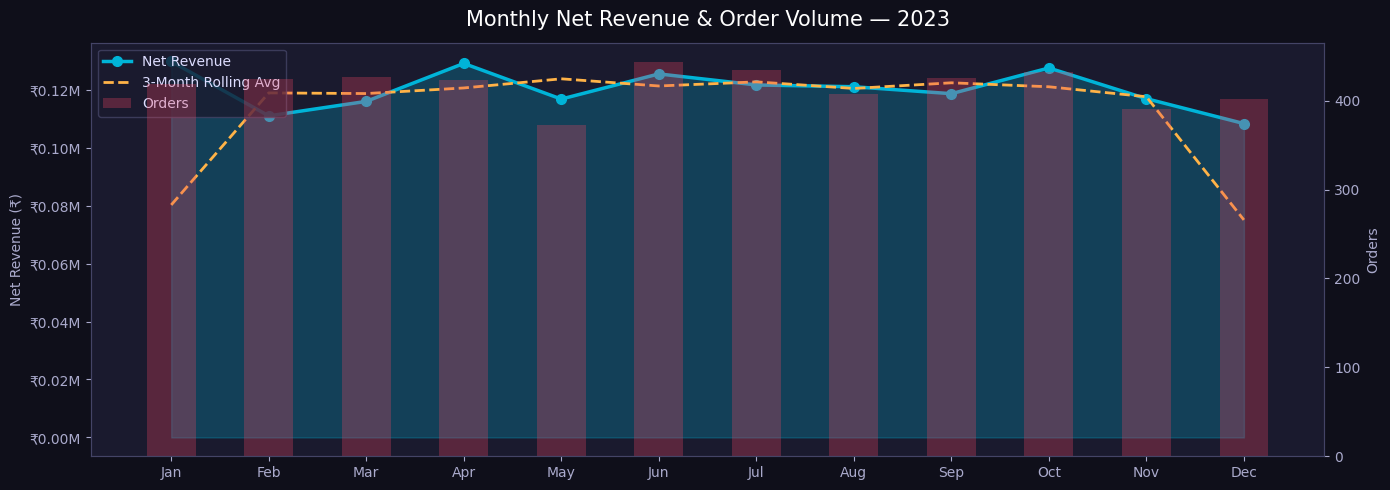

✅  Plot saved → plot1_monthly_trend.png


In [8]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(monthly['month_label'], monthly['total_rev'],
                 alpha=0.25, color=PALETTE[0])
ax1.plot(monthly['month_label'], monthly['total_rev'],
         color=PALETTE[0], lw=2.5, marker='o', ms=7, label='Net Revenue')
ax1.plot(monthly['month_label'], monthly['rolling_3m'],
         color=PALETTE[3], lw=2, ls='--', label='3-Month Rolling Avg')

ax2 = ax1.twinx()
ax2.bar(monthly['month_label'], monthly['orders'],
        alpha=0.30, color=PALETTE[1], width=0.5, label='Orders')
ax2.tick_params(colors='#aaaacc')
ax2.set_ylabel('Orders', color='#aaaacc')

ax1.set_title('Monthly Net Revenue & Order Volume — 2023', fontsize=15, pad=12)
ax1.set_ylabel('Net Revenue (₹)', color='#aaaacc')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x/1e6:.2f}M'))

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc='upper left')

plt.tight_layout()
plt.savefig('plot1_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot1_monthly_trend.png")


## 9. Visualisation 2 — Category Revenue Share

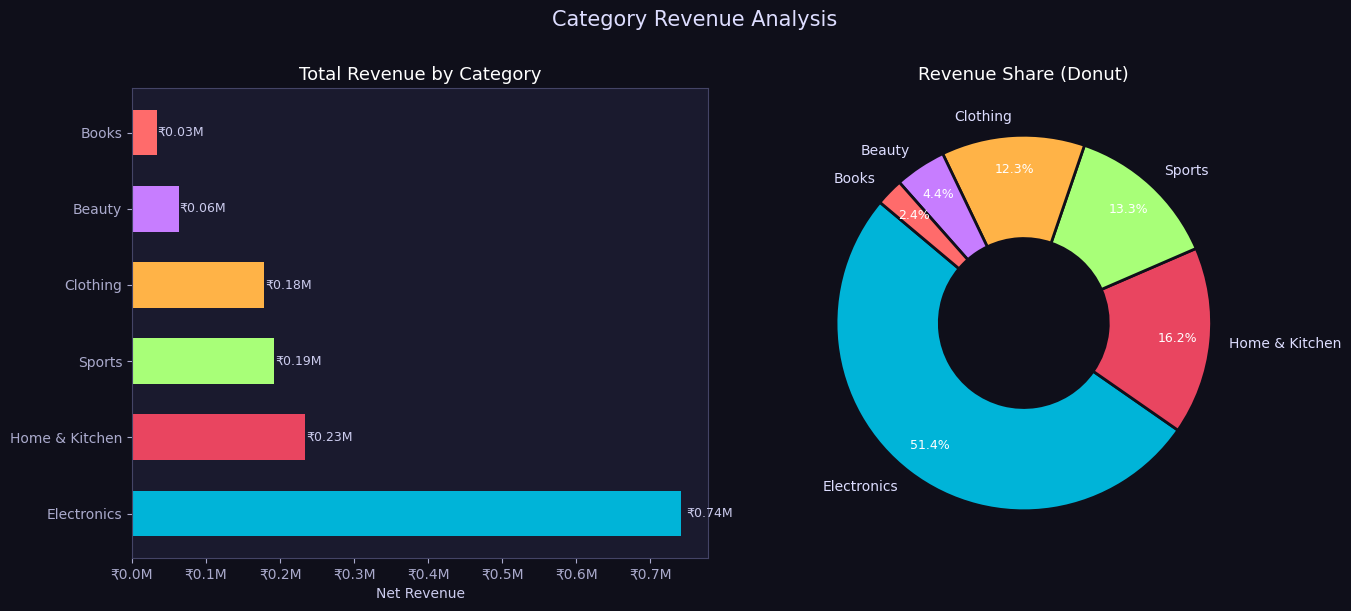

✅  Plot saved → plot2_category.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar
bars = ax1.barh(cat_summary.index, cat_summary['total_rev'],
                color=PALETTE[:len(cat_summary)], edgecolor='none', height=0.6)
for bar, val in zip(bars, cat_summary['total_rev']):
    ax1.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
             f'₹{val/1e6:.2f}M', va='center', fontsize=9, color='#ccccee')
ax1.set_title('Total Revenue by Category', fontsize=13)
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
ax1.set_xlabel('Net Revenue')

# Donut pie
wedges, texts, autotexts = ax2.pie(
    cat_summary['total_rev'],
    labels=cat_summary.index,
    colors=PALETTE[:len(cat_summary)],
    autopct='%1.1f%%',
    pctdistance=0.82,
    wedgeprops={'width':0.55, 'edgecolor':'#0f0f1a', 'linewidth':2},
    startangle=140
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color('#ffffff')
ax2.set_title('Revenue Share (Donut)', fontsize=13)

plt.suptitle('Category Revenue Analysis', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('plot2_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot2_category.png")


## 10. Visualisation 3 — Correlation Heatmap

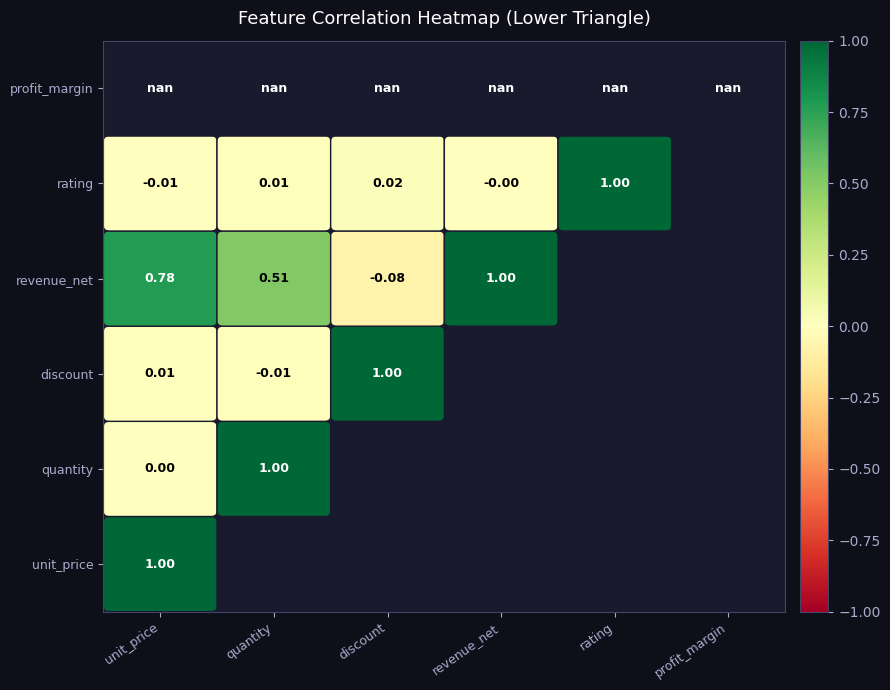

✅  Plot saved → plot3_heatmap.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

mask_upper = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

# Draw lower triangle only
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        if i >= j:
            val  = corr_mat[i, j]
            color= plt.cm.RdYlGn((val + 1) / 2)
            rect = mpatches.FancyBboxPatch((j-0.45, i-0.45), 0.9, 0.9,
                                            boxstyle='round,pad=0.05',
                                            facecolor=color, edgecolor='#1a1a2e',
                                            linewidth=1)
            ax.add_patch(rect)
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=9, color='black' if abs(val) < 0.7 else 'white',
                    fontweight='bold')

ax.set_xlim(-0.5, len(num_cols)-0.5)
ax.set_ylim(-0.5, len(num_cols)-0.5)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)
ax.set_title('Feature Correlation Heatmap (Lower Triangle)', fontsize=13, pad=12)

from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=Normalize(vmin=-1, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)

plt.tight_layout()
plt.savefig('plot3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot3_heatmap.png")


## 11. Visualisation 4 — Revenue Distribution & Box Plots

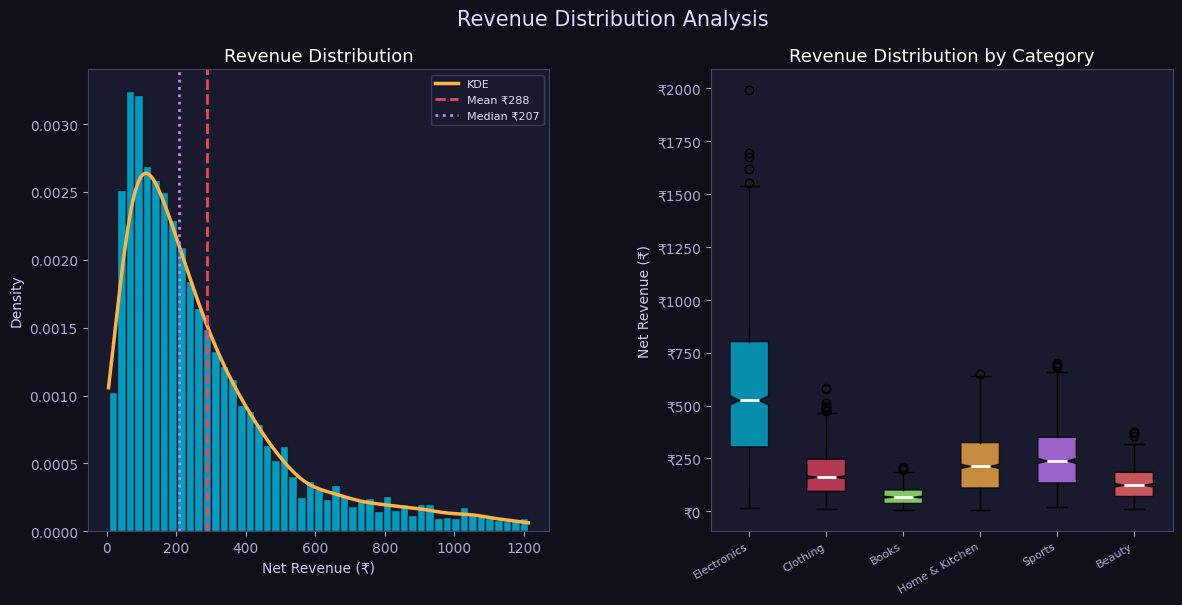

✅  Plot saved → plot4_distribution.png


In [11]:
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# Histogram + KDE
ax1 = fig.add_subplot(gs[0])
rev_clean = df['revenue_net'].values
bins = np.linspace(rev_clean.min(), np.percentile(rev_clean, 99), 50)
ax1.hist(rev_clean, bins=bins, color=PALETTE[0], edgecolor='#0f0f1a',
         alpha=0.85, density=True)

# Manual KDE overlay using NumPy Gaussian
x_range = np.linspace(bins[0], bins[-1], 300)
bw      = 1.06 * np.std(rev_clean) * len(rev_clean)**(-0.2)
kde     = np.mean(np.exp(-0.5*((x_range[:,None] - rev_clean)/bw)**2), axis=1) / (bw*np.sqrt(2*np.pi))
ax1.plot(x_range, kde, color=PALETTE[3], lw=2.5, label='KDE')
ax1.axvline(np.mean(rev_clean), color=PALETTE[1], lw=2, ls='--', label=f'Mean ₹{np.mean(rev_clean):.0f}')
ax1.axvline(np.median(rev_clean),color=PALETTE[4], lw=2, ls=':', label=f'Median ₹{np.median(rev_clean):.0f}')
ax1.set_title('Revenue Distribution', fontsize=13)
ax1.set_xlabel('Net Revenue (₹)')
ax1.set_ylabel('Density')
ax1.legend(fontsize=8)

# Box plot per category
ax2 = fig.add_subplot(gs[1])
data_per_cat = [df.loc[df['category']==c, 'revenue_net'].values for c in categories]
bp = ax2.boxplot(data_per_cat, patch_artist=True, notch=True,
                 medianprops={'color':'white','linewidth':2})
for patch, col in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax2.set_xticklabels(categories, rotation=30, ha='right', fontsize=8)
ax2.set_title('Revenue Distribution by Category', fontsize=13)
ax2.set_ylabel('Net Revenue (₹)')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x:.0f}'))

plt.suptitle('Revenue Distribution Analysis', fontsize=15)
plt.savefig('plot4_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot4_distribution.png")


## 12. Visualisation 5 — Region × Channel Revenue Heatmap

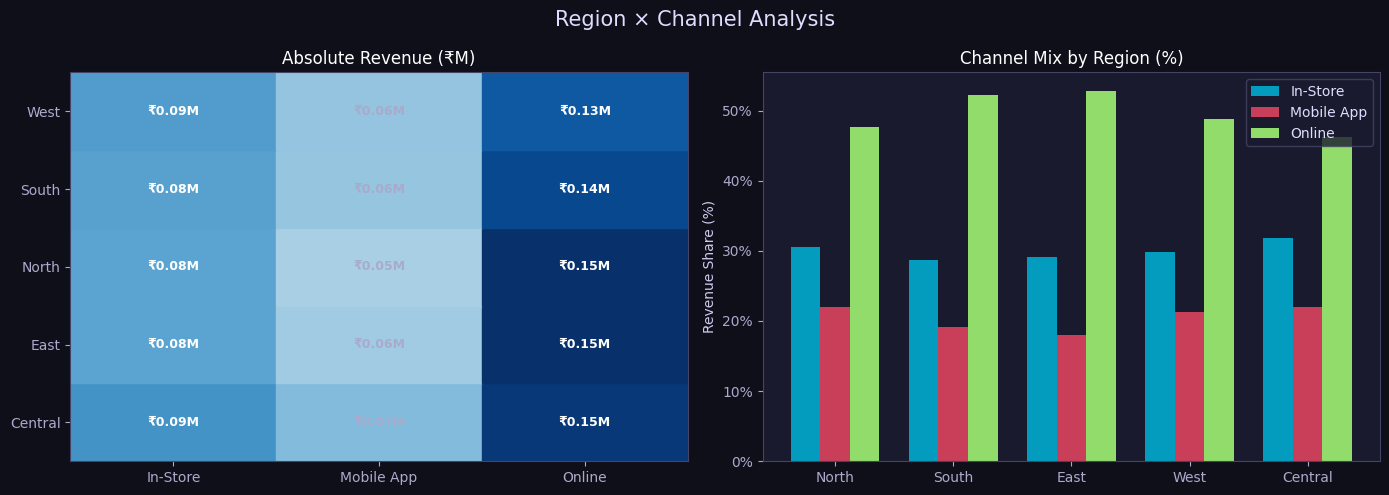

✅  Plot saved → plot5_region_channel.png


In [12]:
pivot = df.pivot_table(values='revenue_net', index='region',
                       columns='channel', aggfunc='sum')
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100  # row-normalised %

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute heatmap
for i, region in enumerate(pivot.index):
    for j, channel in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        color = plt.cm.Blues(val / pivot.values.max())
        ax1.add_patch(plt.Rectangle((j, i), 1, 1, color=color))
        ax1.text(j+0.5, i+0.5, f'₹{val/1e6:.2f}M', ha='center', va='center',
                 fontsize=9, fontweight='bold',
                 color='white' if val/pivot.values.max()>0.5 else '#aaaacc')

ax1.set_xlim(0, len(pivot.columns))
ax1.set_ylim(0, len(pivot.index))
ax1.set_xticks(np.arange(len(pivot.columns))+0.5)
ax1.set_yticks(np.arange(len(pivot.index))+0.5)
ax1.set_xticklabels(pivot.columns)
ax1.set_yticklabels(pivot.index)
ax1.set_title('Absolute Revenue (₹M)', fontsize=12)

# Normalised grouped bar
x = np.arange(len(regions))
width = 0.25
for k, (ch, col) in enumerate(zip(pivot_norm.columns, PALETTE)):
    ax2.bar(x + k*width, pivot_norm[ch], width, label=ch,
            color=col, alpha=0.85, edgecolor='none')
ax2.set_xticks(x + width)
ax2.set_xticklabels(regions)
ax2.set_ylabel('Revenue Share (%)')
ax2.set_title('Channel Mix by Region (%)', fontsize=12)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.legend()

plt.suptitle('Region × Channel Analysis', fontsize=15)
plt.tight_layout()
plt.savefig('plot5_region_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot5_region_channel.png")


## 13. Visualisation 6 — Discount vs Revenue Scatter (by Category)

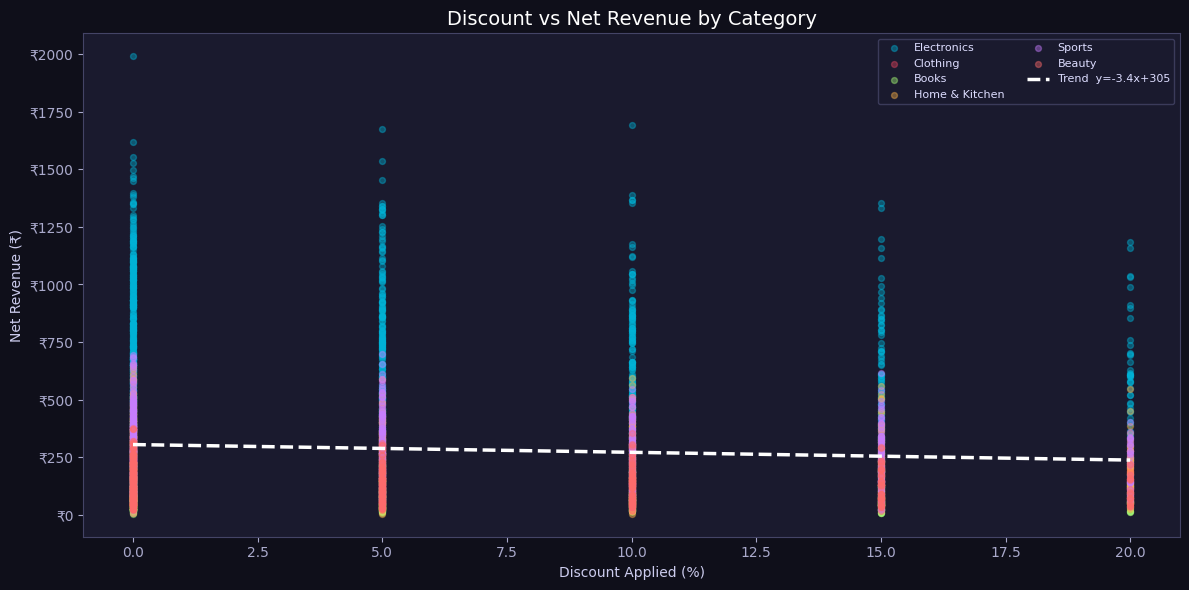

✅  Plot saved → plot6_scatter.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

for cat, col in zip(categories, PALETTE):
    sub = df[df['category']==cat]
    ax.scatter(sub['discount']*100, sub['revenue_net'],
               color=col, alpha=0.4, s=18, label=cat)

# Trend line with NumPy polyfit
x = df['discount'].values * 100
y = df['revenue_net'].values
mask = ~np.isnan(x) & ~np.isnan(y)
coef = np.polyfit(x[mask], y[mask], 1)
x_line = np.linspace(0, 20, 100)
ax.plot(x_line, np.polyval(coef, x_line), color='white', lw=2.5,
        ls='--', label=f'Trend  y={coef[0]:.1f}x+{coef[1]:.0f}')

ax.set_xlabel('Discount Applied (%)')
ax.set_ylabel('Net Revenue (₹)')
ax.set_title('Discount vs Net Revenue by Category', fontsize=14)
ax.legend(fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x:.0f}'))

plt.tight_layout()
plt.savefig('plot6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot6_scatter.png")


## 14. Visualisation 7 — Customer Rating Analysis

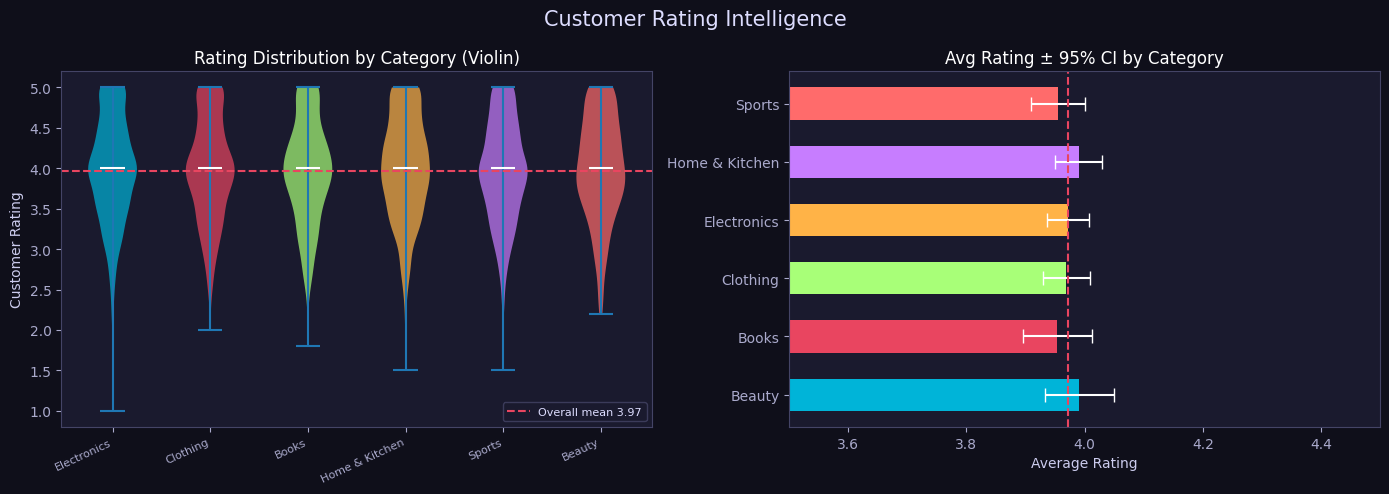

✅  Plot saved → plot7_ratings.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
parts = axes[0].violinplot([df.loc[df['category']==c,'rating'].dropna() for c in categories],
                            showmedians=True, showextrema=True)
for pc, col in zip(parts['bodies'], PALETTE):
    pc.set_facecolor(col)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('white')
axes[0].set_xticks(range(1, len(categories)+1))
axes[0].set_xticklabels(categories, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Customer Rating')
axes[0].set_title('Rating Distribution by Category (Violin)', fontsize=12)
axes[0].axhline(df['rating'].mean(), color=PALETTE[1], ls='--', lw=1.5,
                label=f'Overall mean {df["rating"].mean():.2f}')
axes[0].legend(fontsize=8)

# Average rating + CI
cat_rating = df.groupby('category')['rating'].agg(['mean','std','count'])
ci = 1.96 * cat_rating['std'] / np.sqrt(cat_rating['count'])
axes[1].barh(cat_rating.index, cat_rating['mean'],
             xerr=ci, color=PALETTE[:len(categories)],
             edgecolor='none', height=0.55, capsize=5,
             error_kw={'elinewidth':1.5,'ecolor':'white'})
axes[1].axvline(df['rating'].mean(), color=PALETTE[1], ls='--', lw=1.5)
axes[1].set_xlabel('Average Rating')
axes[1].set_title('Avg Rating ± 95% CI by Category', fontsize=12)
axes[1].set_xlim(3.5, 4.5)

plt.suptitle('Customer Rating Intelligence', fontsize=15)
plt.tight_layout()
plt.savefig('plot7_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot7_ratings.png")


## 15. Visualisation 8 — Monthly Revenue Stack by Category

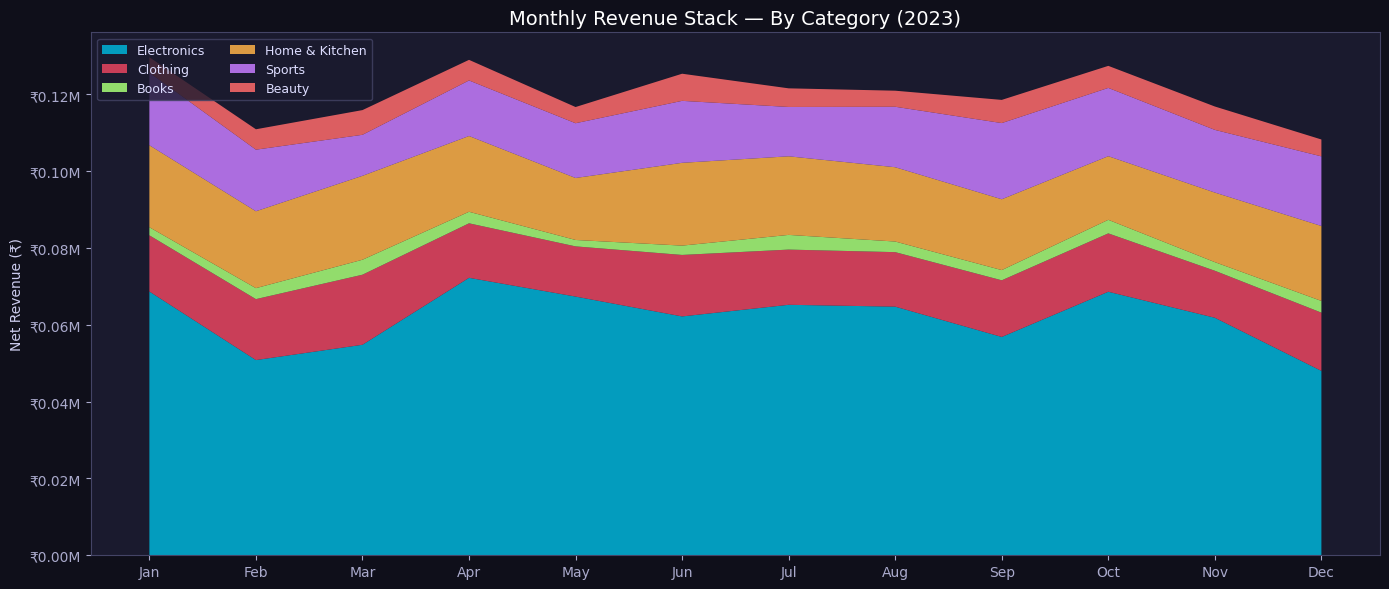

✅  Plot saved → plot8_stacked_area.png


In [15]:
pivot_monthly = df.pivot_table(values='revenue_net', index='month_num',
                                columns='category', aggfunc='sum').fillna(0)
labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(range(1,13), [pivot_monthly[c].values for c in categories],
             labels=categories, colors=PALETTE, alpha=0.85)
ax.set_xticks(range(1,13))
ax.set_xticklabels(labels)
ax.set_ylabel('Net Revenue (₹)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x/1e6:.2f}M'))
ax.set_title('Monthly Revenue Stack — By Category (2023)', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('plot8_stacked_area.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Plot saved → plot8_stacked_area.png")


## 16. Visualisation 9 — KPI Executive Dashboard

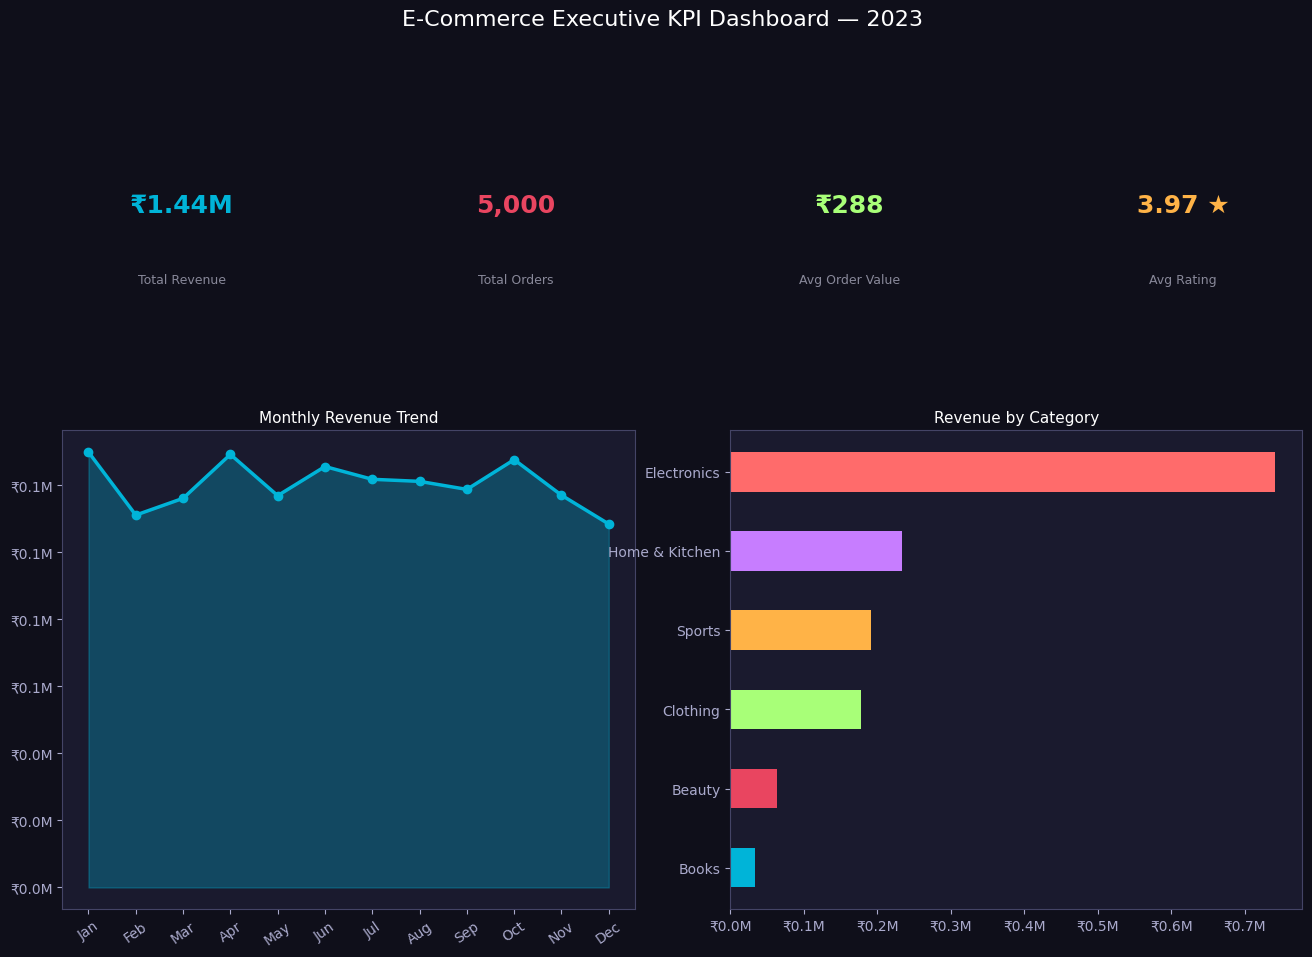

✅  KPI Dashboard saved → plot9_kpi_dashboard.png


In [16]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

total_rev   = df['revenue_net'].sum()
total_orders= len(df)
avg_order   = df['revenue_net'].mean()
avg_rating  = df['rating'].mean()
avg_discount= df['discount'].mean() * 100
top_category= cat_summary.index[0]

kpis = [
    (f'₹{total_rev/1e6:.2f}M', 'Total Revenue', PALETTE[0]),
    (f'{total_orders:,}',       'Total Orders',  PALETTE[1]),
    (f'₹{avg_order:.0f}',       'Avg Order Value',PALETTE[2]),
    (f'{avg_rating:.2f} ★',     'Avg Rating',    PALETTE[3]),
    (f'{avg_discount:.1f}%',    'Avg Discount',  PALETTE[4]),
    (top_category,              'Top Category',  PALETTE[5]),
]

for k, (val, label, col) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, k % 4] if k < 4 else gs[1, k-4])
    ax.set_facecolor('#16213e')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.text(0.5, 0.65, val, ha='center', va='center', fontsize=18,
            fontweight='bold', color=col, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=9,
            color='#888899', transform=ax.transAxes)
    for spine in ['top','bottom','left','right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(col)
        ax.spines[spine].set_linewidth(2)

# Revenue trend subplot
ax_trend = fig.add_subplot(gs[1:, :2])
ax_trend.fill_between(monthly['month_label'], monthly['total_rev'], alpha=0.3, color=PALETTE[0])
ax_trend.plot(monthly['month_label'], monthly['total_rev'],
              color=PALETTE[0], lw=2.5, marker='o', ms=6)
ax_trend.set_title('Monthly Revenue Trend', fontsize=11)
ax_trend.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
ax_trend.tick_params(axis='x', rotation=35)

# Top category bar
ax_bar = fig.add_subplot(gs[1:, 2:])
sorted_cats = cat_summary.sort_values('total_rev')
bars = ax_bar.barh(sorted_cats.index, sorted_cats['total_rev'],
                   color=PALETTE[:len(sorted_cats)], edgecolor='none', height=0.5)
ax_bar.set_title('Revenue by Category', fontsize=11)
ax_bar.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))

fig.suptitle('E-Commerce Executive KPI Dashboard — 2023', fontsize=16, y=1.01, color='white')
plt.savefig('plot9_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  KPI Dashboard saved → plot9_kpi_dashboard.png")


## 17. Key Business Insights

In [17]:
print("=" * 60)
print("   E-COMMERCE SALES INTELLIGENCE — KEY INSIGHTS (2023)")
print("=" * 60)

print(f"""
REVENUE OVERVIEW
  • Total Net Revenue       : ₹{df['revenue_net'].sum():>12,.0f}
  • Total Orders            : {len(df):>12,}
  • Average Order Value     : ₹{df['revenue_net'].mean():>12,.2f}

TOP PERFORMER
  • Best Category           : {cat_summary.index[0]} (₹{cat_summary['total_rev'].iloc[0]/1e6:.2f}M)
  • Best Region             : {df.groupby('region')['revenue_net'].sum().idxmax()}
  • Best Channel            : {df.groupby('channel')['revenue_net'].sum().idxmax()}

CUSTOMER SENTIMENT
  • Average Rating          : {df['rating'].mean():.2f} / 5.0
  • Highest-Rated Category  : {df.groupby('category')['rating'].mean().idxmax()}

DISCOUNT INSIGHTS
  • Avg Discount Applied    : {df['discount'].mean()*100:.1f}%
  • Orders with No Discount : {(df['discount']==0).sum():,} ({(df['discount']==0).mean()*100:.1f}%)

SEASONAL PEAKS
  • Best Month (Revenue)    : {monthly.set_index('month_label')['total_rev'].idxmax()}
  • Worst Month (Revenue)   : {monthly.set_index('month_label')['total_rev'].idxmin()}
""")
print("=" * 60)
print("✅  Analysis complete!")


   E-COMMERCE SALES INTELLIGENCE — KEY INSIGHTS (2023)

REVENUE OVERVIEW
  • Total Net Revenue       : ₹   1,441,430
  • Total Orders            :        5,000
  • Average Order Value     : ₹      288.29

TOP PERFORMER
  • Best Category           : Electronics (₹0.74M)
  • Best Region             : Central
  • Best Channel            : Online

CUSTOMER SENTIMENT
  • Average Rating          : 3.97 / 5.0
  • Highest-Rated Category  : Beauty

DISCOUNT INSIGHTS
  • Avg Discount Applied    : 5.0%
  • Orders with No Discount : 2,460 (49.2%)

SEASONAL PEAKS
  • Best Month (Revenue)    : Jan
  • Worst Month (Revenue)   : Dec

✅  Analysis complete!
